In [2]:
import os

import pandas as pd
import seaborn as sns

INPUT_DIR = "data"

clinical_fp = os.path.join(INPUT_DIR, "clinical_data.csv")

In [2]:
clinical_df = pd.read_csv(clinical_fp, index_col=0)
clinical_df.head()

,Group,Participant #,Sex,Age,Height m,Weight (kg),Weight at time of surgery,Immediate pre-op BMI,BMI,Glucose,...,Dyslip,OSA,Asthma/COPD,LiverDx,GORD,Sleeve,OAGB,RYGB,SVUH,SMH
Patient,,,,,,,,,,,,,,,,,,,,,
P01,MHO,M130580,F,30.0,1.52,110.0,NaN,NaN,47.6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P02,MHO,M095649,F,43.0,1.54,128.0,128.0,54.0,54.0,5.5,...,0.0,0.0,0.0,0.0,1.0,NaN,1.0,NaN,NaN,1.0
P03,MHO,M130957,F,26.0,1.67,165.0,165.0,59.2,59.0,NaN,...,0.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,1.0
P04,MHO,M130950,F,44.0,1.68,145.0,145.1,51.4,51.5,5.6,...,0.0,1.0,0.0,0.0,1.0,NaN,1.0,NaN,NaN,1.0
P05,MHO,M130949,F,37.0,1.78,134.5,137.6,43.4,42.5,5.2,...,0.0,0.0,0.0,0.0,0.0,NaN,1.0,NaN,NaN,1.0


<Axes: xlabel='Age', ylabel='BMI'>

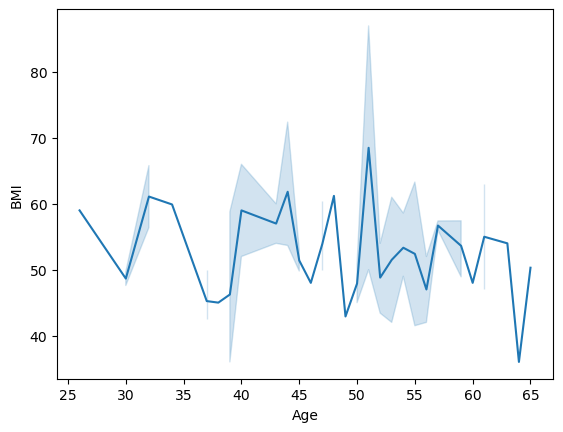

In [4]:
sns.lineplot(data=clinical_df, x="Age", y="BMI")

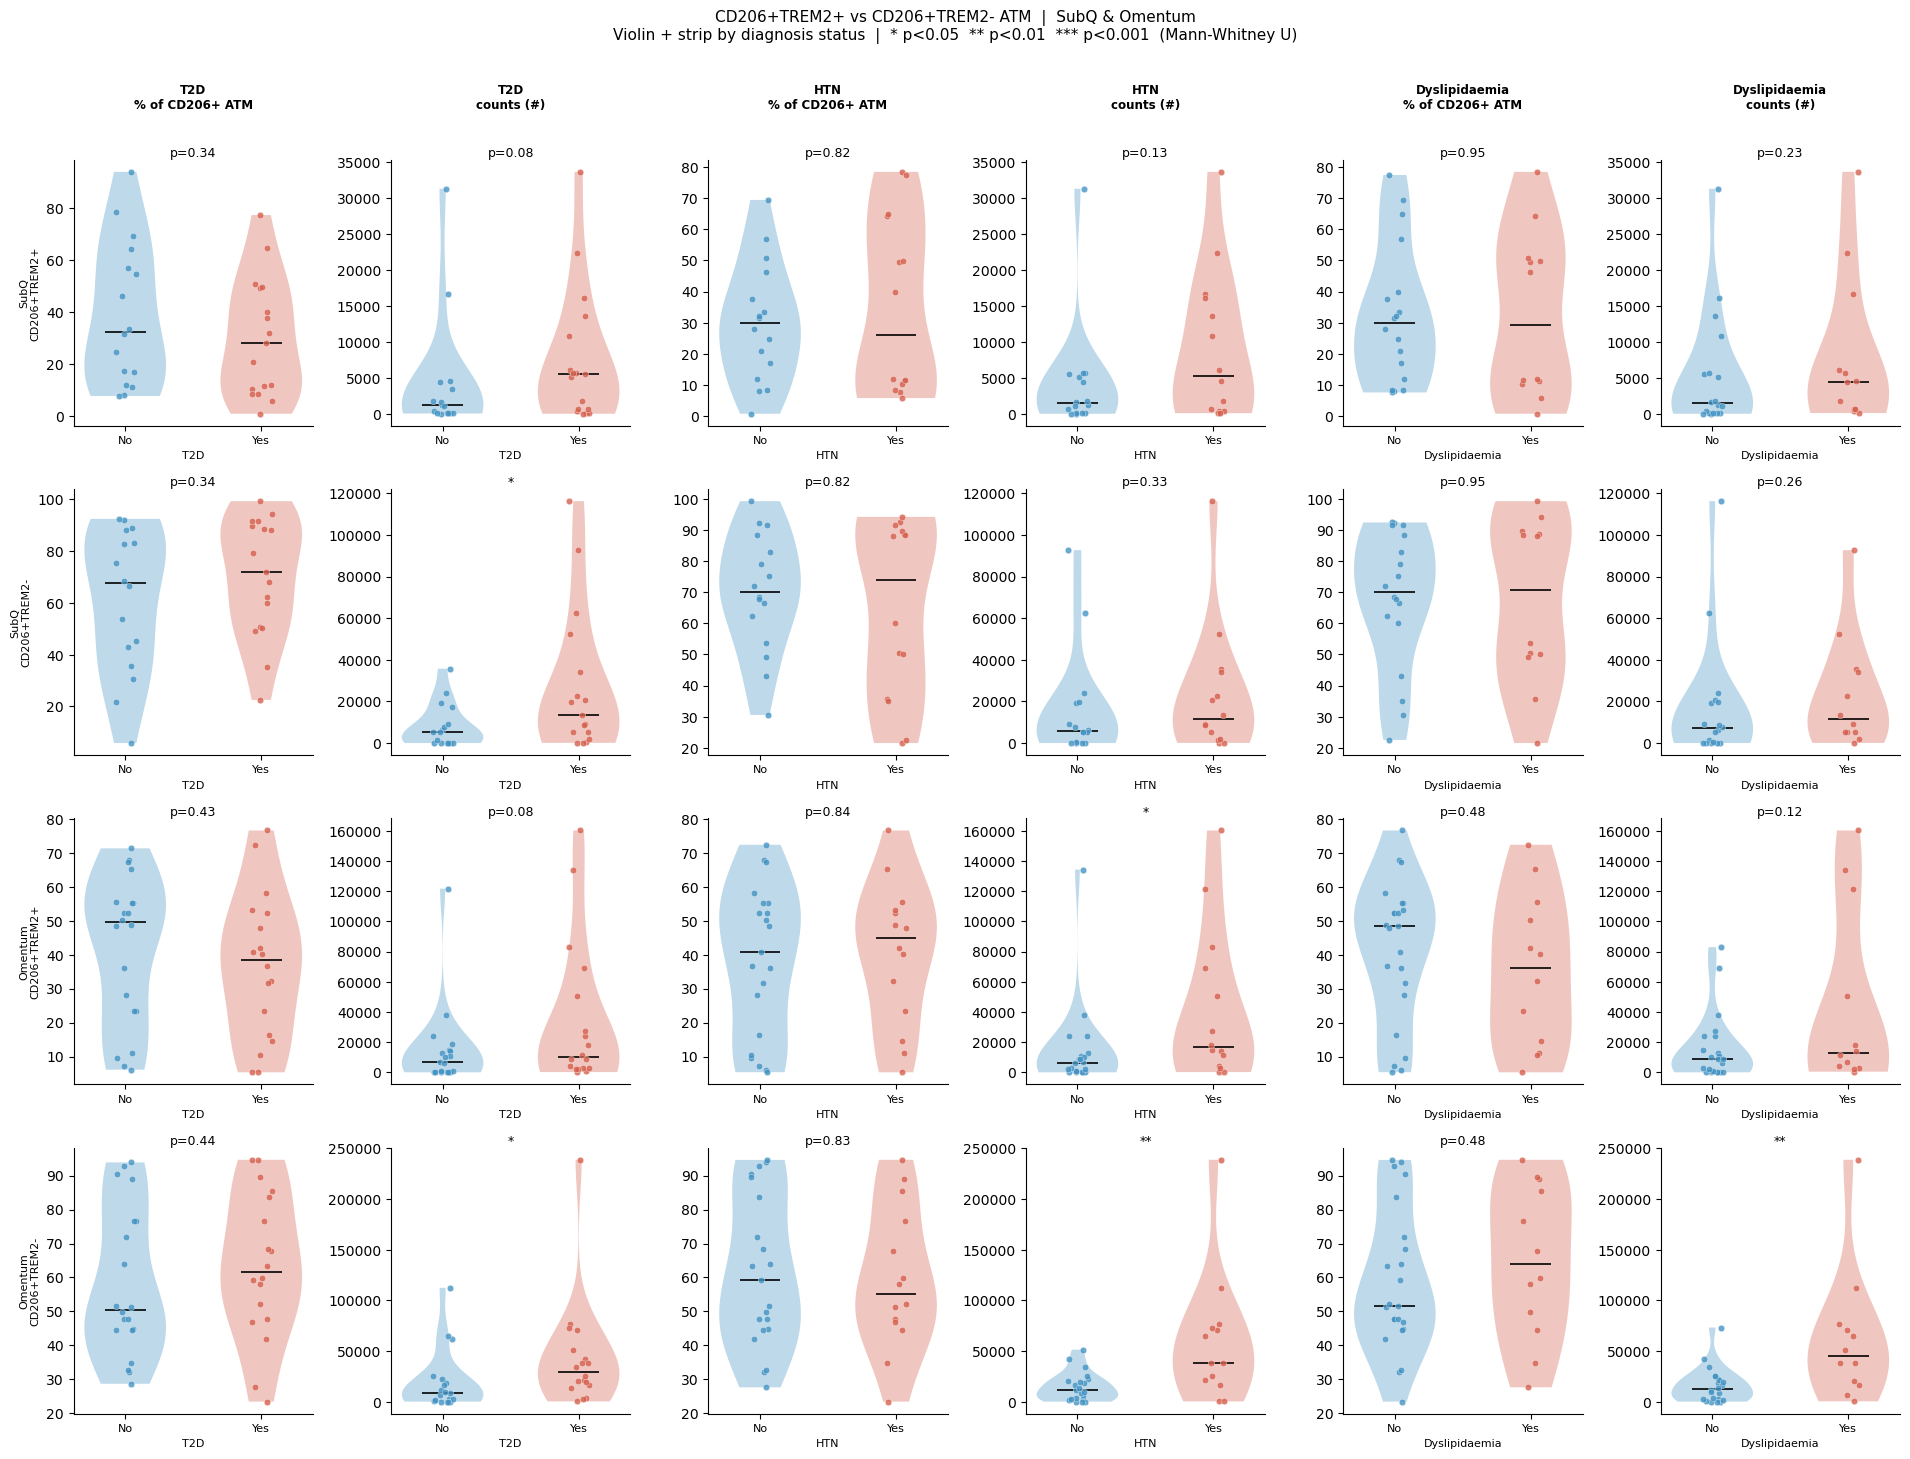

In [11]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu

# ── Data ───────────────────────────────────────────────────────
pct = pd.read_csv("data/flow_cytometry_perct_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
cnt = pd.read_csv("data/flow_cytometry_counts_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
pct.index = pct.index.str.strip()
cnt.index = cnt.index.str.strip()
pct = pct.apply(pd.to_numeric, errors="coerce")
cnt = cnt.apply(pd.to_numeric, errors="coerce")

clinical = pd.read_csv("data/clinical_data.csv", index_col=0)
clinical.index = clinical.index.str.strip()

# ── Columns of interest ────────────────────────────────────────
# TREM2+ and TREM2- within CD206+ ATM, for SubQ and Omentum only
# (ATMs are tissue macrophages — not present in Blood panel)
# PCT_COLS = {
#     "SubQ":    ["SubQ_CD206+TREM2+ ATM % of CD45+",   "SubQ_CD206+TREM2- ATM % of CD45+"],
#     "Omentum": ["Omentum_CD206+TREM2+ ATM % of CD45+", "Omentum_CD206+TREM2- ATM % of CD45+"],
# }
PCT_COLS = {
    "SubQ":    ["SubQ_TREM2+ % of CD206+ ATM",   "SubQ_TREM2- % of CD206+ ATM"],
    "Omentum": ["Omentum_TREM2+ % of CD206+ ATM", "Omentum_TREM2- % of CD206+ ATM"],


}
CNT_COLS = {
    "SubQ":    ["SubQ_CD206+TREM2+ ATM #",   "SubQ_CD206+TREM2- ATM #"],
    "Omentum": ["Omentum_CD206+TREM2+ ATM #", "Omentum_CD206+TREM2- ATM #"],
}
POP_LABELS  = ["CD206+TREM2+", "CD206+TREM2-"]
DIAGNOSES   = {"T2D": "T2D", "HTN": "HTN", "Dyslip": "Dyslipidaemia"}
DIAG_LABELS = {0: "No", 1: "Yes"}
DIAG_COLORS = {0: "#4393C3", 1: "#D6604D"}

tissues = ["SubQ", "Omentum"]

def mwu_p(a, b):
    """Mann-Whitney U p-value; returns np.nan if insufficient data."""

    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

def pstar(p):
    if np.isnan(p): return "n/a"
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return f"p={p:.2f}"

# ── Layout ─────────────────────────────────────────────────────
# Rows:    tissues × populations  (4 rows: SubQ TREM2+, SubQ TREM2-, Om TREM2+, Om TREM2-)
# Columns: pct | cnt  × diagnoses (3 diagnoses × 2 measure types = 6 cols)
# → 4 rows × 6 cols grid, each cell is one violin+strip

n_rows   = len(tissues) * len(POP_LABELS)   # 4
n_diag   = len(DIAGNOSES)                   # 3
n_mtype  = 2                                # pct, cnt
n_cols   = n_diag * n_mtype                 # 6

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3.2, n_rows * 3.6),
                          sharey=False)

col_headers = []
for diag_col, diag_label in DIAGNOSES.items():
    col_headers += [f"{diag_label}\n% of CD206+ ATM", f"{diag_label}\ncounts (#)"]


for row_i, (tissue, pop_i) in enumerate(
        [(t, p) for t in tissues for p in range(len(POP_LABELS))]):

    pop_label = POP_LABELS[pop_i]
    pct_col   = PCT_COLS[tissue][pop_i]
    cnt_col   = CNT_COLS[tissue][pop_i]

    for col_i, (diag_col, diag_label) in enumerate(DIAGNOSES.items()):

        for mtype_i, (data_df, feat_col, unit) in enumerate([
                (pct, pct_col, "% of CD206+ ATM"),
                (cnt, cnt_col,  "counts (#)"),
        ]):
            ax = axes[row_i, col_i * 2 + mtype_i]

            common = data_df.index.intersection(clinical.index)
            vals   = data_df.loc[common, feat_col].values.astype(float) \
                     if feat_col in data_df.columns else np.full(len(common), np.nan)
            groups = clinical.loc[common, diag_col].values.astype(float)

            for g_val, x_pos in [(0, 0), (1, 1)]:
                mask  = groups == g_val
                gvals = vals[mask]
                color = DIAG_COLORS[g_val]

                # violin (skip if too few)
                if np.sum(~np.isnan(gvals)) >= 4:
                    vp = ax.violinplot(gvals[~np.isnan(gvals)],
                                       positions=[x_pos], widths=0.6,
                                       showmedians=True, showextrema=False)
                    for pc in vp["bodies"]:
                        pc.set_facecolor(color); pc.set_alpha(0.35)
                    vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(1.2)

                # strip
                jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=mask.sum())
                ax.scatter(np.full(mask.sum(), x_pos) + jitter, gvals,
                           color=color, s=22, alpha=0.8,
                           edgecolors="white", linewidths=0.3, zorder=3)

            # Mann-Whitney U
            g0 = vals[groups == 0]; g1 = vals[groups == 1]
            p  = mwu_p(g0, g1)
            ax.set_title(pstar(p), fontsize=9, pad=2)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["No", "Yes"], fontsize=8)
            ax.set_xlabel(diag_label, fontsize=8)
            if col_i == 0 and mtype_i == 0:
                ax.set_ylabel(f"{tissue}\n{pop_label}", fontsize=8)
            sns.despine(ax=ax)

# Column headers above row 0
for col_i, header in enumerate(col_headers):
    axes[0, col_i].annotate(header, xy=(0.5, 1.18), xycoords="axes fraction",
                             ha="center", va="bottom", fontsize=8.5, fontweight="bold")

fig.suptitle(
    "CD206+TREM2+ vs CD206+TREM2- ATM  |  SubQ & Omentum\n"
    "Violin + strip by diagnosis status  |  * p<0.05  ** p<0.01  *** p<0.001  (Mann-Whitney U)",
    fontsize=11, y=1.01,
)
fig.tight_layout()
plt.show()


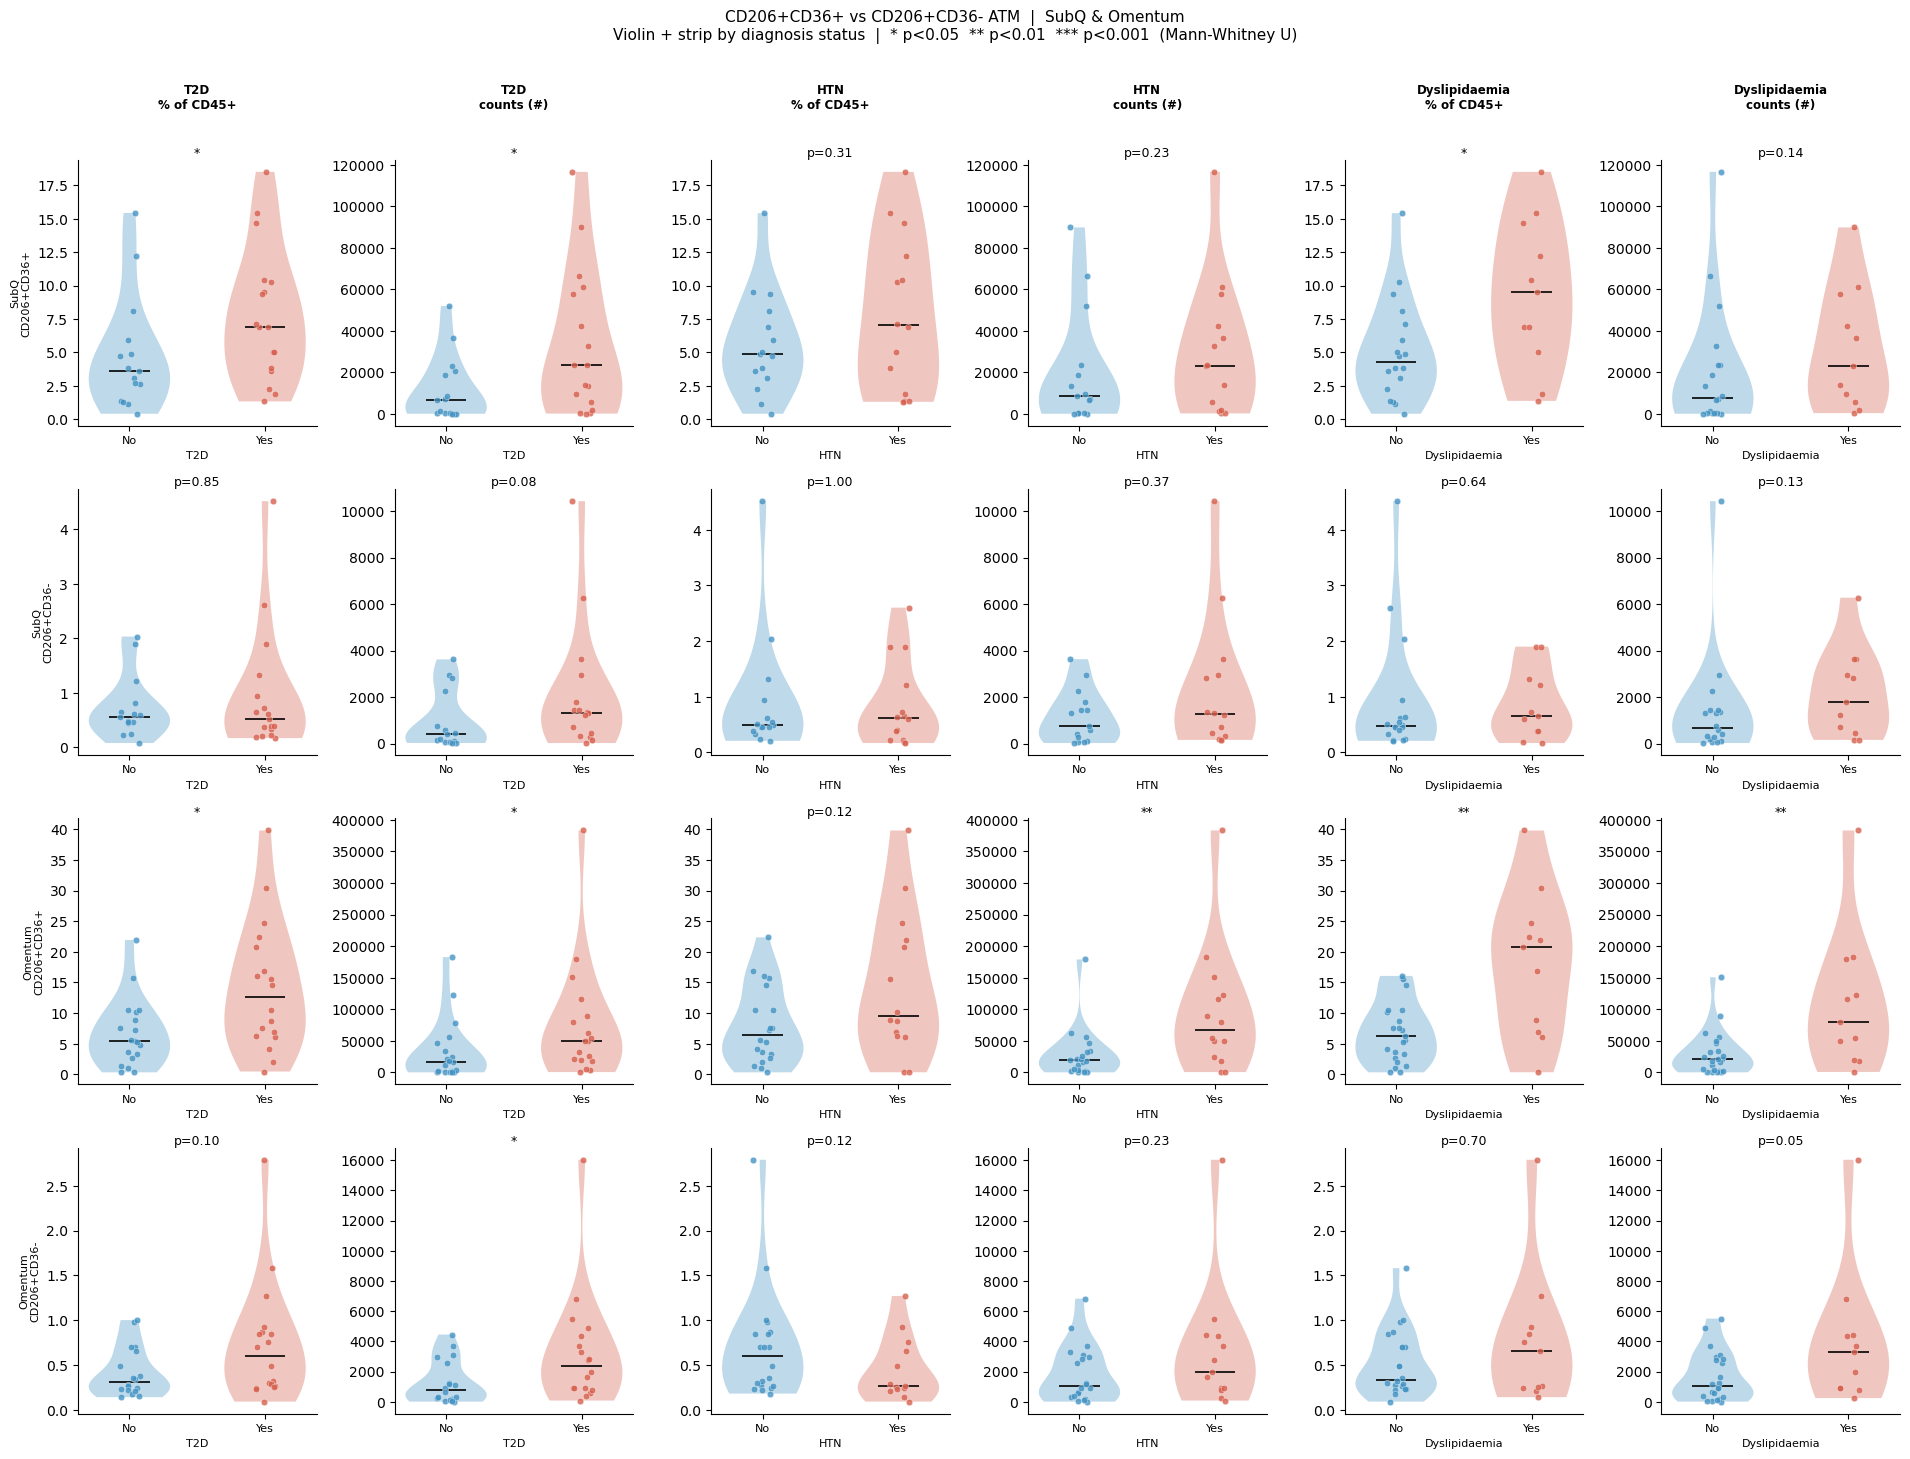

In [6]:
# ── Data ───────────────────────────────────────────────────────
pct = pd.read_csv("data/flow_cytometry_perct_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
cnt = pd.read_csv("data/flow_cytometry_counts_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
pct.index = pct.index.str.strip()
cnt.index = cnt.index.str.strip()
pct = pct.apply(pd.to_numeric, errors="coerce")
cnt = cnt.apply(pd.to_numeric, errors="coerce")

clinical = pd.read_csv("data/clinical_data.csv", index_col=0)
clinical.index = clinical.index.str.strip()

# ── Columns of interest ────────────────────────────────────────
# TREM2+ and TREM2- within CD206+ ATM, for SubQ and Omentum only
# (ATMs are tissue macrophages — not present in Blood panel)
PCT_COLS = {
    "SubQ":    ["SubQ_CD206+CD36+ ATM % of CD45+",   "SubQ_CD206+CD36- ATM % of CD45+"],
    "Omentum": ["Omentum_CD206+CD36+ ATM % of CD45+", "Omentum_CD206+CD36- ATM % of CD45+"],
}
CNT_COLS = {
    "SubQ":    ["SubQ_CD206+CD36+ ATM #",   "SubQ_CD206+CD36- ATM  #"],
    "Omentum": ["Omentum_CD206+CD36+ ATM #", "Omentum_CD206+CD36- ATM  #"],
}
POP_LABELS  = ["CD206+CD36+", "CD206+CD36-"]
DIAGNOSES   = {"T2D": "T2D", "HTN": "HTN", "Dyslip": "Dyslipidaemia"}
DIAG_LABELS = {0: "No", 1: "Yes"}
DIAG_COLORS = {0: "#4393C3", 1: "#D6604D"}

tissues = ["SubQ", "Omentum"]

def mwu_p(a, b):
    """Mann-Whitney U p-value; returns np.nan if insufficient data."""

    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

def pstar(p):
    if np.isnan(p): return "n/a"
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return f"p={p:.2f}"

# ── Layout ─────────────────────────────────────────────────────
# Rows:    tissues × populations  (4 rows: SubQ TREM2+, SubQ TREM2-, Om TREM2+, Om TREM2-)
# Columns: pct | cnt  × diagnoses (3 diagnoses × 2 measure types = 6 cols)
# → 4 rows × 6 cols grid, each cell is one violin+strip

n_rows   = len(tissues) * len(POP_LABELS)   # 4
n_diag   = len(DIAGNOSES)                   # 3
n_mtype  = 2                                # pct, cnt
n_cols   = n_diag * n_mtype                 # 6

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3.2, n_rows * 3.6),
                          sharey=False)

col_headers = []
for diag_col, diag_label in DIAGNOSES.items():
    col_headers += [f"{diag_label}\n% of CD45+", f"{diag_label}\ncounts (#)"]


for row_i, (tissue, pop_i) in enumerate(
        [(t, p) for t in tissues for p in range(len(POP_LABELS))]):

    pop_label = POP_LABELS[pop_i]
    pct_col   = PCT_COLS[tissue][pop_i]
    cnt_col   = CNT_COLS[tissue][pop_i]

    for col_i, (diag_col, diag_label) in enumerate(DIAGNOSES.items()):

        for mtype_i, (data_df, feat_col, unit) in enumerate([
                (pct, pct_col, "% of CD45+"),
                (cnt, cnt_col,  "counts (#)"),
        ]):
            ax = axes[row_i, col_i * 2 + mtype_i]

            common = data_df.index.intersection(clinical.index)
            vals   = data_df.loc[common, feat_col].values.astype(float) \
                     if feat_col in data_df.columns else np.full(len(common), np.nan)
            groups = clinical.loc[common, diag_col].values.astype(float)

            for g_val, x_pos in [(0, 0), (1, 1)]:
                mask  = groups == g_val
                gvals = vals[mask]
                color = DIAG_COLORS[g_val]

                # violin (skip if too few)
                if np.sum(~np.isnan(gvals)) >= 4:
                    vp = ax.violinplot(gvals[~np.isnan(gvals)],
                                       positions=[x_pos], widths=0.6,
                                       showmedians=True, showextrema=False)
                    for pc in vp["bodies"]:
                        pc.set_facecolor(color); pc.set_alpha(0.35)
                    vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(1.2)

                # strip
                jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=mask.sum())
                ax.scatter(np.full(mask.sum(), x_pos) + jitter, gvals,
                           color=color, s=22, alpha=0.8,
                           edgecolors="white", linewidths=0.3, zorder=3)

            # Mann-Whitney U
            g0 = vals[groups == 0]; g1 = vals[groups == 1]
            p  = mwu_p(g0, g1)
            ax.set_title(pstar(p), fontsize=9, pad=2)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["No", "Yes"], fontsize=8)
            ax.set_xlabel(diag_label, fontsize=8)
            if col_i == 0 and mtype_i == 0:
                ax.set_ylabel(f"{tissue}\n{pop_label}", fontsize=8)
            sns.despine(ax=ax)

# Column headers above row 0
for col_i, header in enumerate(col_headers):
    axes[0, col_i].annotate(header, xy=(0.5, 1.18), xycoords="axes fraction",
                             ha="center", va="bottom", fontsize=8.5, fontweight="bold")

fig.suptitle(
    "CD206+CD36+ vs CD206+CD36- ATM  |  SubQ & Omentum\n"
    "Violin + strip by diagnosis status  |  * p<0.05  ** p<0.01  *** p<0.001  (Mann-Whitney U)",
    fontsize=11, y=1.01,
)
fig.tight_layout()
plt.show()


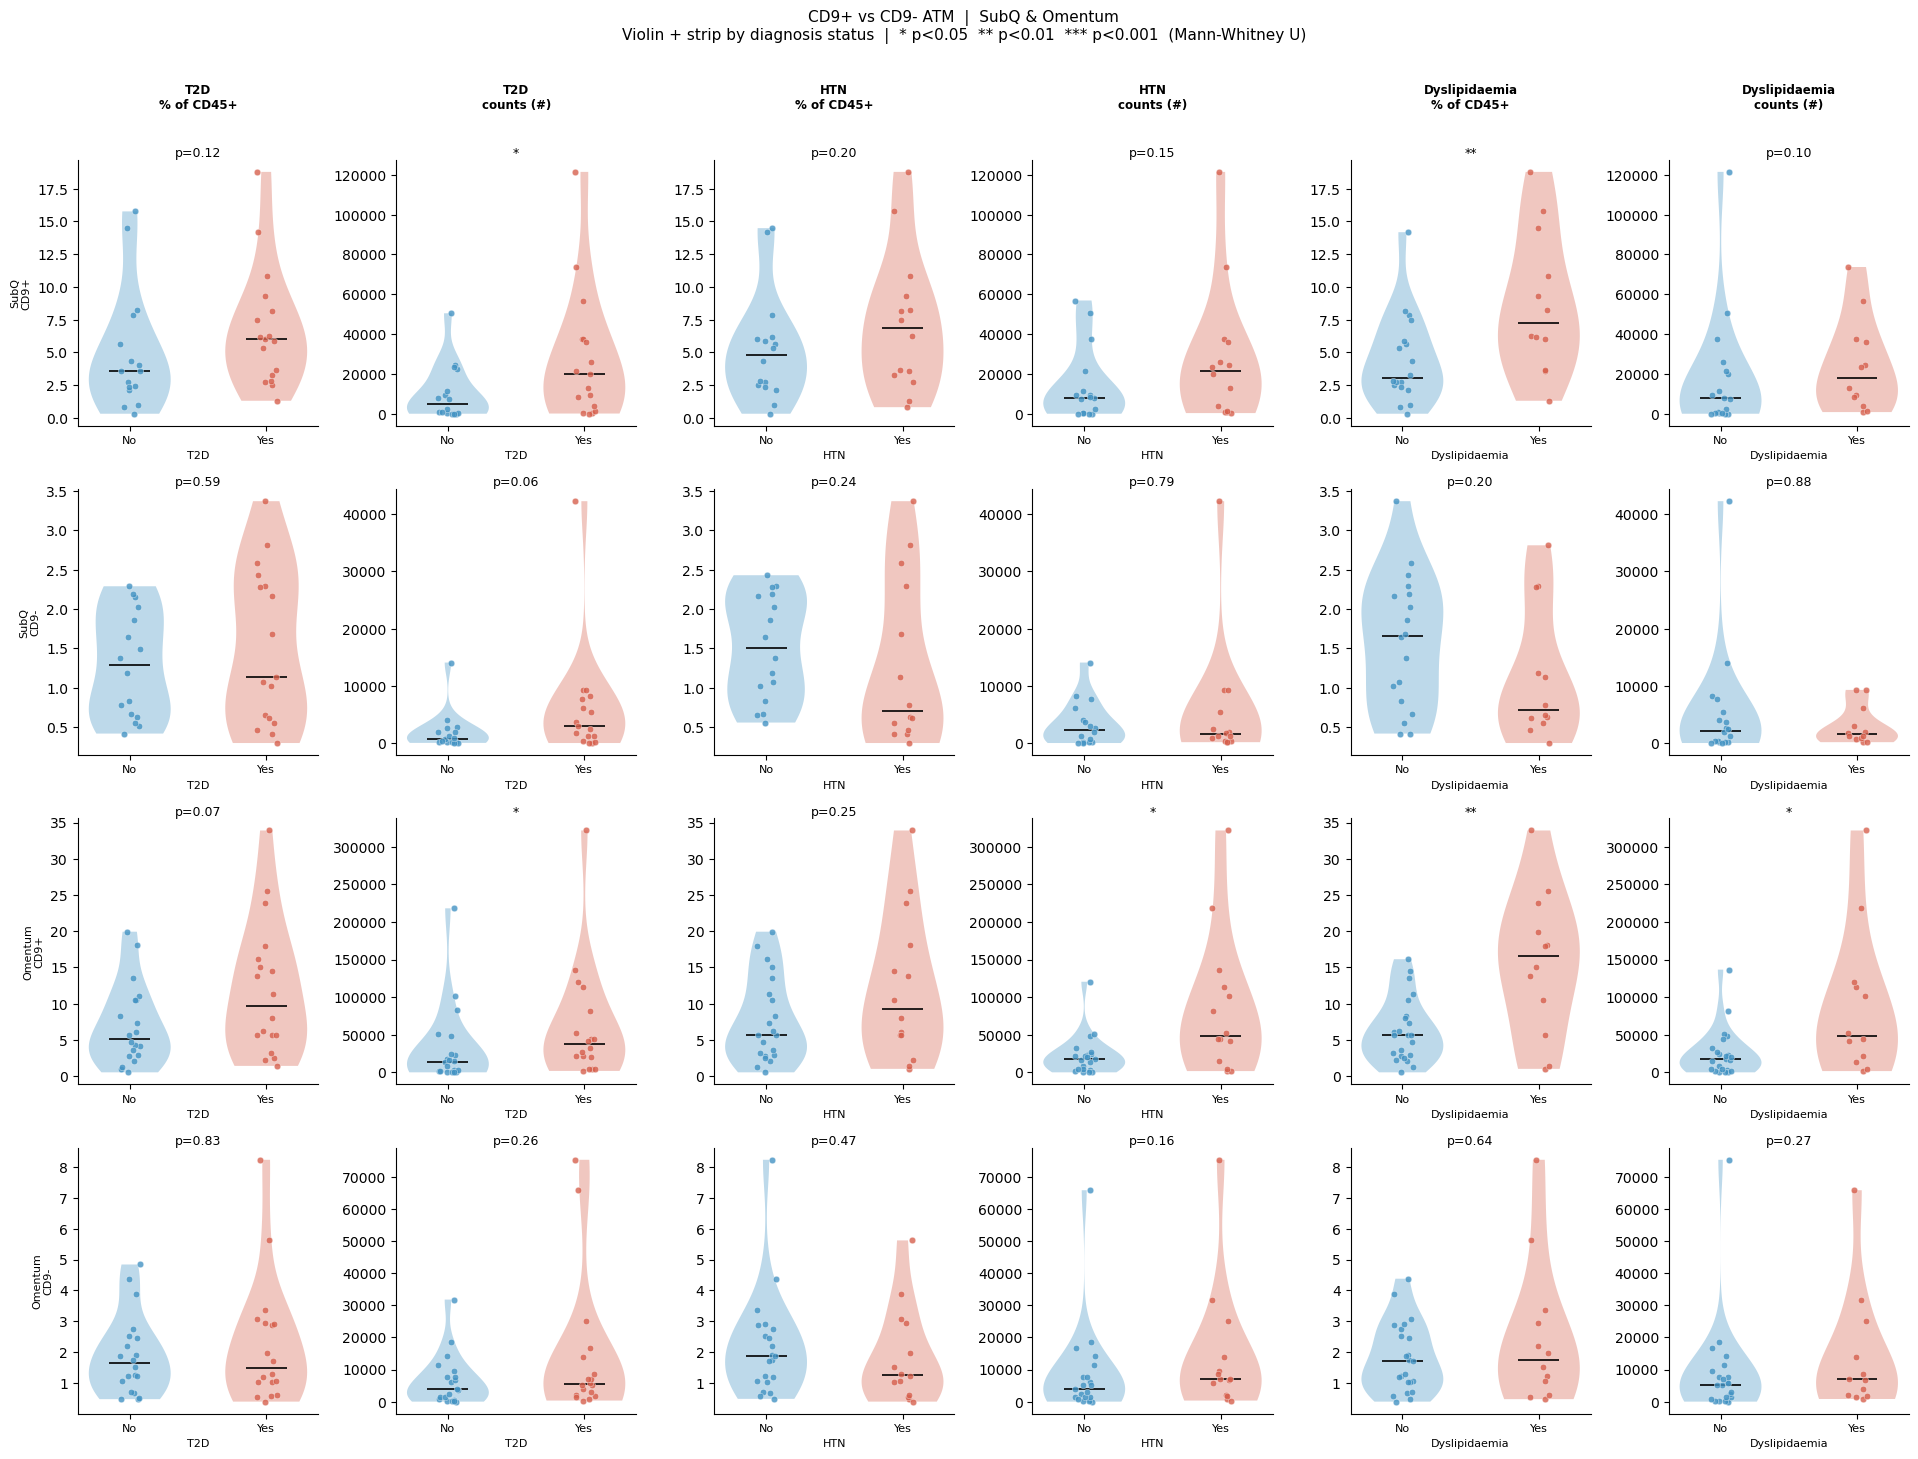

In [15]:
# ── Data ───────────────────────────────────────────────────────
pct = pd.read_csv("data/flow_cytometry_perct_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
cnt = pd.read_csv("data/flow_cytometry_counts_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
pct.index = pct.index.str.strip()
cnt.index = cnt.index.str.strip()
pct = pct.apply(pd.to_numeric, errors="coerce")
cnt = cnt.apply(pd.to_numeric, errors="coerce")

clinical = pd.read_csv("data/clinical_data.csv", index_col=0)
clinical.index = clinical.index.str.strip()

# ── Columns of interest ────────────────────────────────────────
# TREM2+ and TREM2- within CD206+ ATM, for SubQ and Omentum only
# (ATMs are tissue macrophages — not present in Blood panel)
PCT_COLS = {
    "SubQ":    ["SubQ_CD9+ ATM % of CD45+",   "SubQ_CD9- ATM % of CD45+"],
    "Omentum": ["Omentum_CD9+ ATM % of CD45+", "Omentum_CD9- ATM % of CD45+"],
}
CNT_COLS = {
    "SubQ":    ["SubQ_CD9+ ATM % #",   "SubQ_CD9- ATM %  #"],
    "Omentum": ["Omentum_CD9+ ATM % #", "Omentum_CD9- ATM %  #"],
}
POP_LABELS  = ["CD9+", "CD9-"]
DIAGNOSES   = {"T2D": "T2D", "HTN": "HTN", "Dyslip": "Dyslipidaemia"}
DIAG_LABELS = {0: "No", 1: "Yes"}
DIAG_COLORS = {0: "#4393C3", 1: "#D6604D"}

tissues = ["SubQ", "Omentum"]

def mwu_p(a, b):
    """Mann-Whitney U p-value; returns np.nan if insufficient data."""

    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

def pstar(p):
    if np.isnan(p): return "n/a"
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return f"p={p:.2f}"

# ── Layout ─────────────────────────────────────────────────────
# Rows:    tissues × populations  (4 rows: SubQ TREM2+, SubQ TREM2-, Om TREM2+, Om TREM2-)
# Columns: pct | cnt  × diagnoses (3 diagnoses × 2 measure types = 6 cols)
# → 4 rows × 6 cols grid, each cell is one violin+strip

n_rows   = len(tissues) * len(POP_LABELS)   # 4
n_diag   = len(DIAGNOSES)                   # 3
n_mtype  = 2                                # pct, cnt
n_cols   = n_diag * n_mtype                 # 6

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3.2, n_rows * 3.6),
                          sharey=False)

col_headers = []
for diag_col, diag_label in DIAGNOSES.items():
    col_headers += [f"{diag_label}\n% of CD45+", f"{diag_label}\ncounts (#)"]


for row_i, (tissue, pop_i) in enumerate(
        [(t, p) for t in tissues for p in range(len(POP_LABELS))]):

    pop_label = POP_LABELS[pop_i]
    pct_col   = PCT_COLS[tissue][pop_i]
    cnt_col   = CNT_COLS[tissue][pop_i]

    for col_i, (diag_col, diag_label) in enumerate(DIAGNOSES.items()):

        for mtype_i, (data_df, feat_col, unit) in enumerate([
                (pct, pct_col, "% of CD45+"),
                (cnt, cnt_col,  "counts (#)"),
        ]):
            ax = axes[row_i, col_i * 2 + mtype_i]

            common = data_df.index.intersection(clinical.index)
            vals   = data_df.loc[common, feat_col].values.astype(float) \
                     if feat_col in data_df.columns else np.full(len(common), np.nan)
            groups = clinical.loc[common, diag_col].values.astype(float)

            for g_val, x_pos in [(0, 0), (1, 1)]:
                mask  = groups == g_val
                gvals = vals[mask]
                color = DIAG_COLORS[g_val]

                # violin (skip if too few)
                if np.sum(~np.isnan(gvals)) >= 4:
                    vp = ax.violinplot(gvals[~np.isnan(gvals)],
                                       positions=[x_pos], widths=0.6,
                                       showmedians=True, showextrema=False)
                    for pc in vp["bodies"]:
                        pc.set_facecolor(color); pc.set_alpha(0.35)
                    vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(1.2)

                # strip
                jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=mask.sum())
                ax.scatter(np.full(mask.sum(), x_pos) + jitter, gvals,
                           color=color, s=22, alpha=0.8,
                           edgecolors="white", linewidths=0.3, zorder=3)

            # Mann-Whitney U
            g0 = vals[groups == 0]; g1 = vals[groups == 1]
            p  = mwu_p(g0, g1)
            ax.set_title(pstar(p), fontsize=9, pad=2)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["No", "Yes"], fontsize=8)
            ax.set_xlabel(diag_label, fontsize=8)
            if col_i == 0 and mtype_i == 0:
                ax.set_ylabel(f"{tissue}\n{pop_label}", fontsize=8)
            sns.despine(ax=ax)

# Column headers above row 0
for col_i, header in enumerate(col_headers):
    axes[0, col_i].annotate(header, xy=(0.5, 1.18), xycoords="axes fraction",
                             ha="center", va="bottom", fontsize=8.5, fontweight="bold")

fig.suptitle(
    "CD9+ vs CD9- ATM  |  SubQ & Omentum\n"
    "Violin + strip by diagnosis status  |  * p<0.05  ** p<0.01  *** p<0.001  (Mann-Whitney U)",
    fontsize=11, y=1.01,
)
fig.tight_layout()
plt.show()


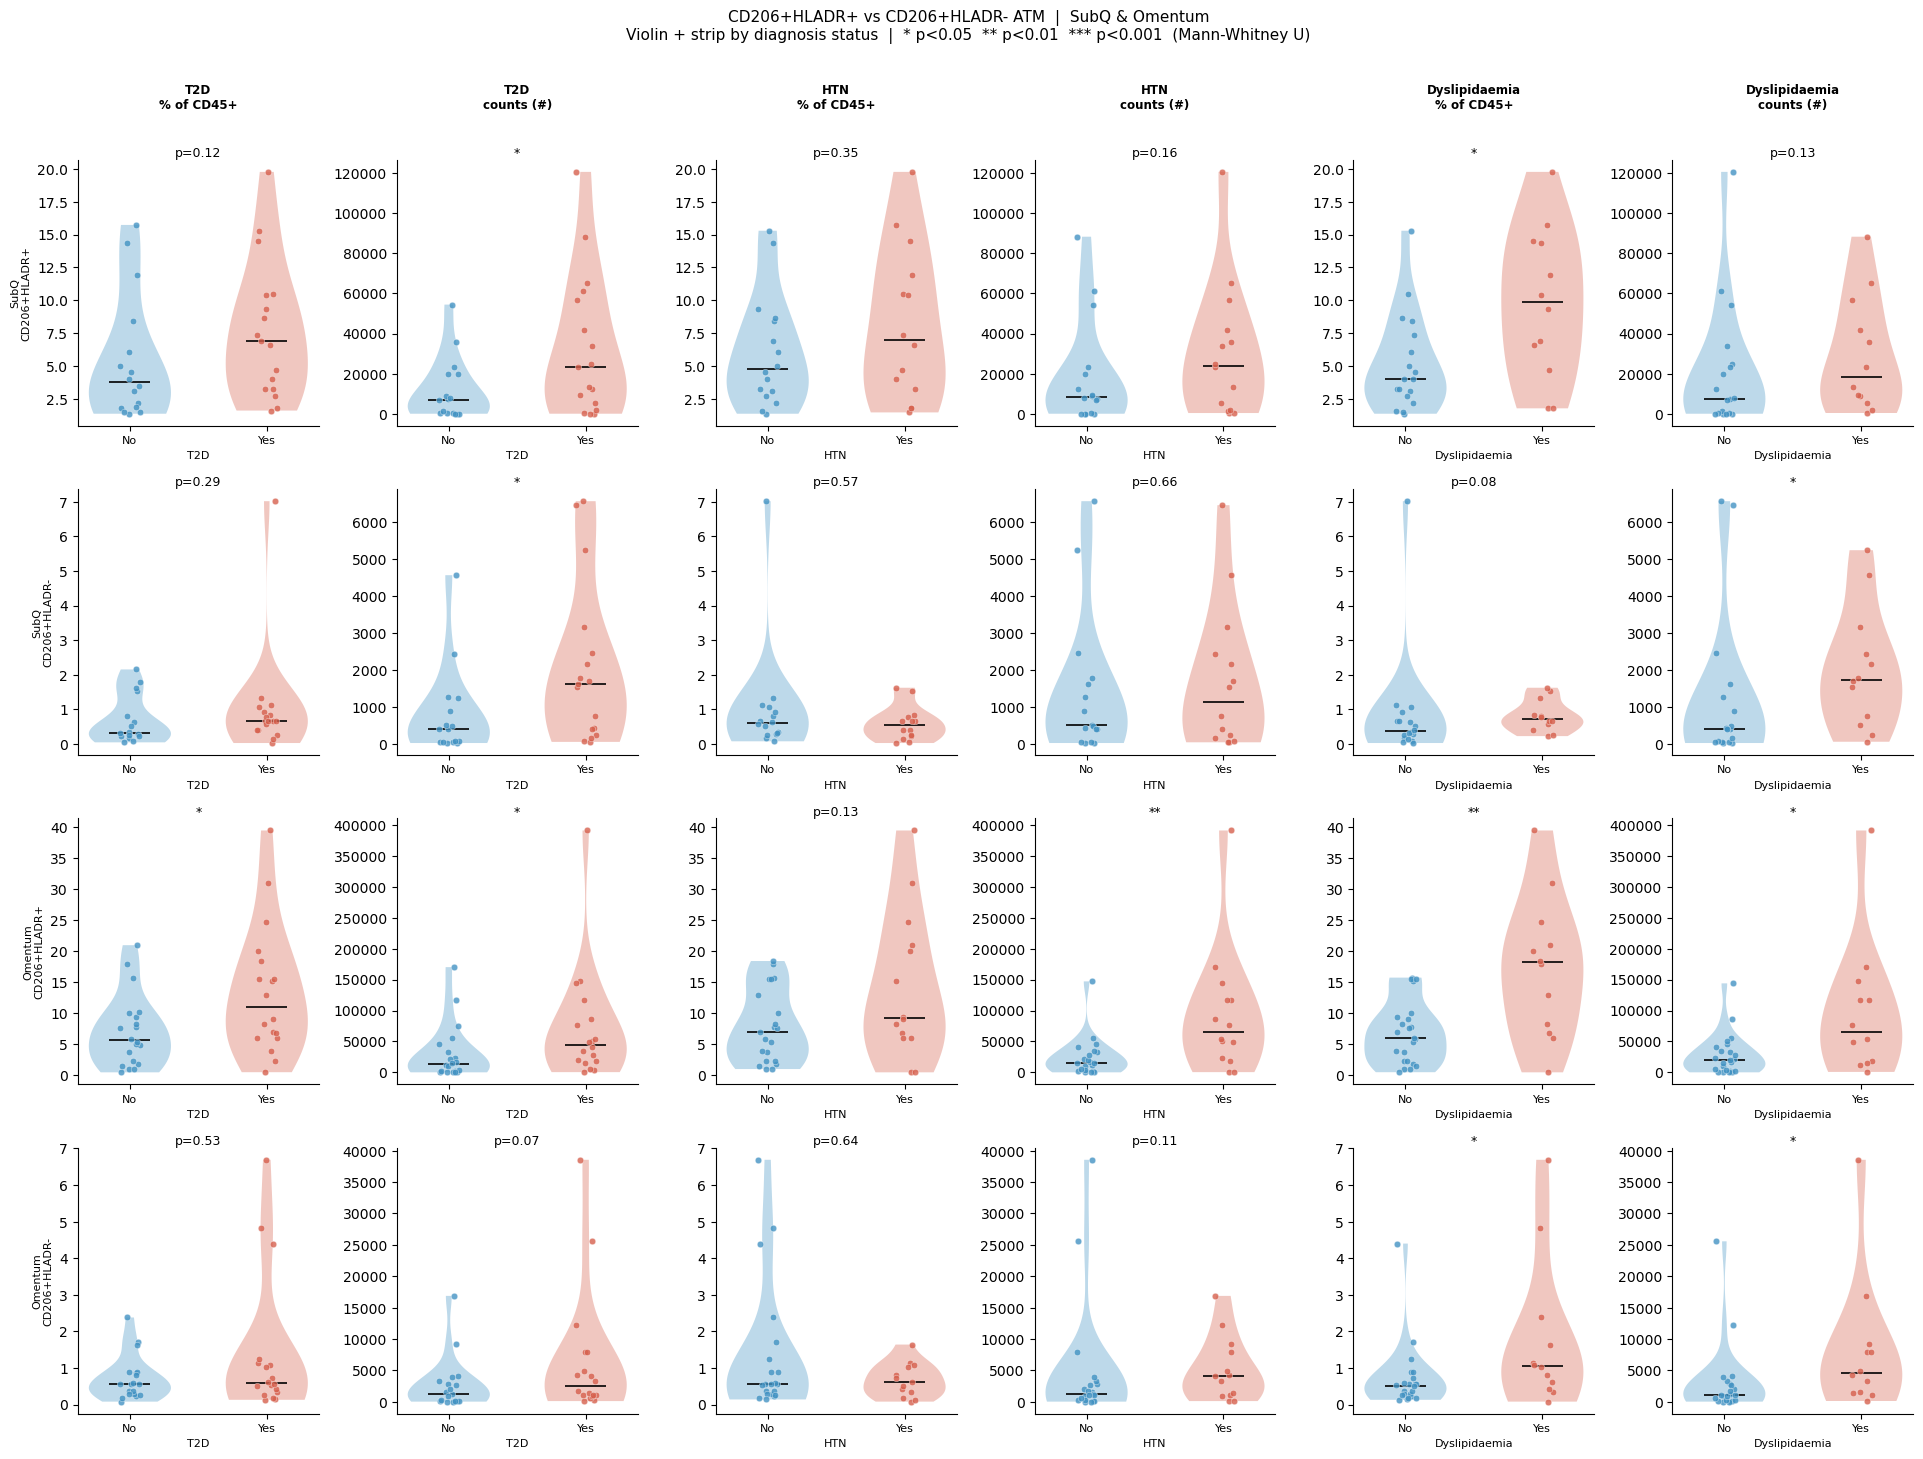

In [8]:
# ── Data ───────────────────────────────────────────────────────
pct = pd.read_csv("data/flow_cytometry_perct_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
cnt = pd.read_csv("data/flow_cytometry_counts_nonstim.csv",
                  index_col=0, encoding="utf-8-sig")
pct.index = pct.index.str.strip()
cnt.index = cnt.index.str.strip()
pct = pct.apply(pd.to_numeric, errors="coerce")
cnt = cnt.apply(pd.to_numeric, errors="coerce")

clinical = pd.read_csv("data/clinical_data.csv", index_col=0)
clinical.index = clinical.index.str.strip()

# ── Columns of interest ────────────────────────────────────────
# TREM2+ and TREM2- within CD206+ ATM, for SubQ and Omentum only
# (ATMs are tissue macrophages — not present in Blood panel)
PCT_COLS = {
    "SubQ":    ["SubQ_CD206+HLADR+ ATM % of CD45+",   "SubQ_CD206+HLADR- ATM % of CD45+"],
    "Omentum": ["Omentum_CD206+HLADR+ ATM % of CD45+", "Omentum_CD206+HLADR- ATM % of CD45+"],
}
CNT_COLS = {
    "SubQ":    ["SubQ_CD206+HLADR+ ATM #",   "SubQ_CD206+HLADR- ATM #"],
    "Omentum": ["Omentum_CD206+HLADR+ ATM #", "Omentum_CD206+HLADR- ATM #"],
}
POP_LABELS  = ["CD206+HLADR+", "CD206+HLADR-"]
DIAGNOSES   = {"T2D": "T2D", "HTN": "HTN", "Dyslip": "Dyslipidaemia"}
DIAG_LABELS = {0: "No", 1: "Yes"}
DIAG_COLORS = {0: "#4393C3", 1: "#D6604D"}

tissues = ["SubQ", "Omentum"]

def mwu_p(a, b):
    """Mann-Whitney U p-value; returns np.nan if insufficient data."""

    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

def pstar(p):
    if np.isnan(p): return "n/a"
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return f"p={p:.2f}"

# ── Layout ─────────────────────────────────────────────────────
# Rows:    tissues × populations  (4 rows: SubQ TREM2+, SubQ TREM2-, Om TREM2+, Om TREM2-)
# Columns: pct | cnt  × diagnoses (3 diagnoses × 2 measure types = 6 cols)
# → 4 rows × 6 cols grid, each cell is one violin+strip

n_rows   = len(tissues) * len(POP_LABELS)   # 4
n_diag   = len(DIAGNOSES)                   # 3
n_mtype  = 2                                # pct, cnt
n_cols   = n_diag * n_mtype                 # 6

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3.2, n_rows * 3.6),
                          sharey=False)

col_headers = []
for diag_col, diag_label in DIAGNOSES.items():
    col_headers += [f"{diag_label}\n% of CD45+", f"{diag_label}\ncounts (#)"]


for row_i, (tissue, pop_i) in enumerate(
        [(t, p) for t in tissues for p in range(len(POP_LABELS))]):

    pop_label = POP_LABELS[pop_i]
    pct_col   = PCT_COLS[tissue][pop_i]
    cnt_col   = CNT_COLS[tissue][pop_i]

    for col_i, (diag_col, diag_label) in enumerate(DIAGNOSES.items()):

        for mtype_i, (data_df, feat_col, unit) in enumerate([
                (pct, pct_col, "% of CD45+"),
                (cnt, cnt_col,  "counts (#)"),
        ]):
            ax = axes[row_i, col_i * 2 + mtype_i]

            common = data_df.index.intersection(clinical.index)
            vals   = data_df.loc[common, feat_col].values.astype(float) \
                     if feat_col in data_df.columns else np.full(len(common), np.nan)
            groups = clinical.loc[common, diag_col].values.astype(float)

            for g_val, x_pos in [(0, 0), (1, 1)]:
                mask  = groups == g_val
                gvals = vals[mask]
                color = DIAG_COLORS[g_val]

                # violin (skip if too few)
                if np.sum(~np.isnan(gvals)) >= 4:
                    vp = ax.violinplot(gvals[~np.isnan(gvals)],
                                       positions=[x_pos], widths=0.6,
                                       showmedians=True, showextrema=False)
                    for pc in vp["bodies"]:
                        pc.set_facecolor(color); pc.set_alpha(0.35)
                    vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(1.2)

                # strip
                jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=mask.sum())
                ax.scatter(np.full(mask.sum(), x_pos) + jitter, gvals,
                           color=color, s=22, alpha=0.8,
                           edgecolors="white", linewidths=0.3, zorder=3)

            # Mann-Whitney U
            g0 = vals[groups == 0]; g1 = vals[groups == 1]
            p  = mwu_p(g0, g1)
            ax.set_title(pstar(p), fontsize=9, pad=2)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["No", "Yes"], fontsize=8)
            ax.set_xlabel(diag_label, fontsize=8)
            if col_i == 0 and mtype_i == 0:
                ax.set_ylabel(f"{tissue}\n{pop_label}", fontsize=8)
            sns.despine(ax=ax)

# Column headers above row 0
for col_i, header in enumerate(col_headers):
    axes[0, col_i].annotate(header, xy=(0.5, 1.18), xycoords="axes fraction",
                             ha="center", va="bottom", fontsize=8.5, fontweight="bold")

fig.suptitle(
    "CD206+HLADR+ vs CD206+HLADR- ATM  |  SubQ & Omentum\n"
    "Violin + strip by diagnosis status  |  * p<0.05  ** p<0.01  *** p<0.001  (Mann-Whitney U)",
    fontsize=11, y=1.01,
)
fig.tight_layout()
plt.show()
